<a href="https://colab.research.google.com/github/ayelefeleke/ASTU-Community-Financial-Inclusion-Hackathon/blob/main/ASTU_Community_Financial_Inclusion_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Required Libraries

I'm install `catboost`, `scikit-learn`, `numpy`, `matplotlib`, and `seaborn` to ensure all necessary tools are available for data preprocessing, model training, and visualization.

In [121]:
!pip install catboost scikit-learn numpy matplotlib seaborn

In [122]:

# Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import shap
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


# To Load the datasets

In [123]:


train = pd.read_csv('/content/Train.csv')
test = pd.read_csv('/content/Test.csv')
variabledefinitions = pd.read_csv('/content/VariableDefinitions.csv')
sampleSabmission=pd.read_csv("/content/SampleSubmission.csv")



Let’s observe the shape of our datasets.

In [124]:
print('train data shape :', train.shape)
print('test data shape :', test.shape)

train data shape : (23524, 13)
test data shape : (10086, 12)


In [125]:
display(train.head())

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [126]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


let see numerical features of train

In [127]:
train.describe()

,year,household_size,age_of_respondent
count,23524.000000,23524.000000,23524.000000
mean,2016.975939,3.797483,38.805220
std,0.847371,2.227613,16.520569
min,2016.000000,1.000000,16.000000
25%,2016.000000,2.000000,26.000000
50%,2017.000000,3.000000,35.000000
75%,2018.000000,5.000000,49.000000
max,2018.000000,21.000000,100.000000


In [128]:
# view the submission file
sampleSabmission.head()

,unique_id,bank_account
0,uniqueid_1 x Kenya,0
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,0
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0


In [129]:
# Let's view the variables
variabledefinitions

,Variable Definitions,Unnamed: 1
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"
5,household_size,Number of people living in one house
6,age_of_respondent,The age of the interviewee
7,gender_of_respondent,"Gender of interviewee: Male, Female"
8,relationship_with_head,The interviewee’s relationship with the head o...
9,marital_status,The martial status of the interviewee: Married...



# TO CHECK MISSING VALUES EXIST


In [130]:


print("Train Missing Values:")
display(train.isnull().sum().sort_values(ascending=False))

print("\nTest Missing Values:")
display(test.isnull().sum().sort_values(ascending=False))

Train Missing Values:


,0
country,0
year,0
uniqueid,0
bank_account,0
location_type,0
cellphone_access,0
household_size,0
age_of_respondent,0
gender_of_respondent,0
relationship_with_head,0



Test Missing Values:


,0
country,0
year,0
uniqueid,0
location_type,0
cellphone_access,0
household_size,0
age_of_respondent,0
gender_of_respondent,0
relationship_with_head,0
marital_status,0


in the above 0 means no missing values so let continue to the next

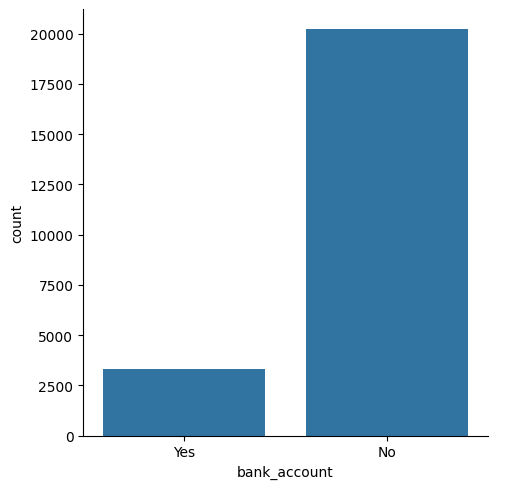

In [131]:
# Explore Target distribution
sns.catplot(x="bank_account", kind="count", data=train)

In [132]:

def create_features(df):

    # young population indicator
    df["young_population"] = (df["age_of_respondent"] < 30).astype(int)

    # elderly indicator
    df["elderly_population"] = (df["age_of_respondent"] > 55).astype(int)

    # large household indicator
    df["large_household"] = (df["household_size"] > 5).astype(int)

    # age / household relationship
    df["age_household_ratio"] = (
        df["age_of_respondent"] /
        (df["household_size"] + 1)
    )

    # urban advantage proxy
    df["urban_advantage"] = (
        df["location_type"] == "Urban"
    ).astype(int)

    # education proxy
    education_map = {
        "No formal education": 0,
        "Primary education": 1,
        "Secondary education": 2,
        "Vocational/Specialised training": 3,
        "Tertiary education": 4,
        "Other/Dont know/RTA": 0
    }

    if "education_level" in df.columns:
        df["education_score"] = df["education_level"].map(education_map)

    return df


train = create_features(train)
test = create_features(test)

# HANDLE MISSING VALUES

In [133]:
TARGET = "bank_account"

for col in train.columns:

    if col == TARGET:
        continue

    if train[col].dtype == "object":
        train[col] = train[col].fillna("Unknown")
        if col in test.columns:
            test[col] = test[col].fillna("Unknown")

    else:
        median_value = train[col].median()
        train[col] = train[col].fillna(median_value)
        if col in test.columns:
            test[col] = test[col].fillna(median_value)

this is some feature engineering i do

## Exploratory Data Analysis (EDA)
here is some EDA i will do
Let's start by understanding the distribution of our target variable, `bank_account`, and then explore other features.

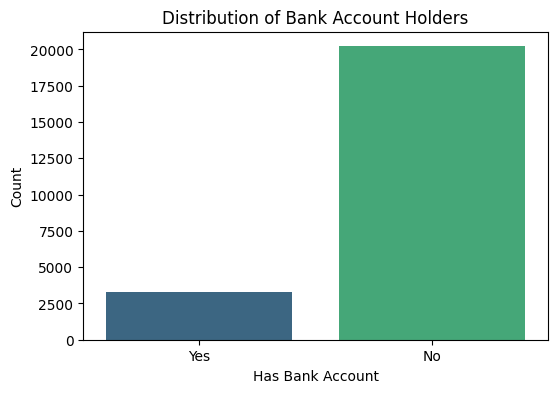

Value counts for bank_account:
bank_account
No     20212
Yes     3312
Name: count, dtype: int64

Percentage distribution:
bank_account
No     85.920762
Yes    14.079238
Name: proportion, dtype: float64


In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='bank_account', data=train, palette='viridis', hue='bank_account', legend=False)
plt.title('Distribution of Bank Account Holders')
plt.xlabel('Has Bank Account')
plt.ylabel('Count')
plt.show()

# Print value counts for better understanding
print('Value counts for bank_account:')
print(train['bank_account'].value_counts())
print('\nPercentage distribution:')
print(train['bank_account'].value_counts(normalize=True) * 100)


Now, let's explore the categorical features to see their unique values and their relationship with the target variable.

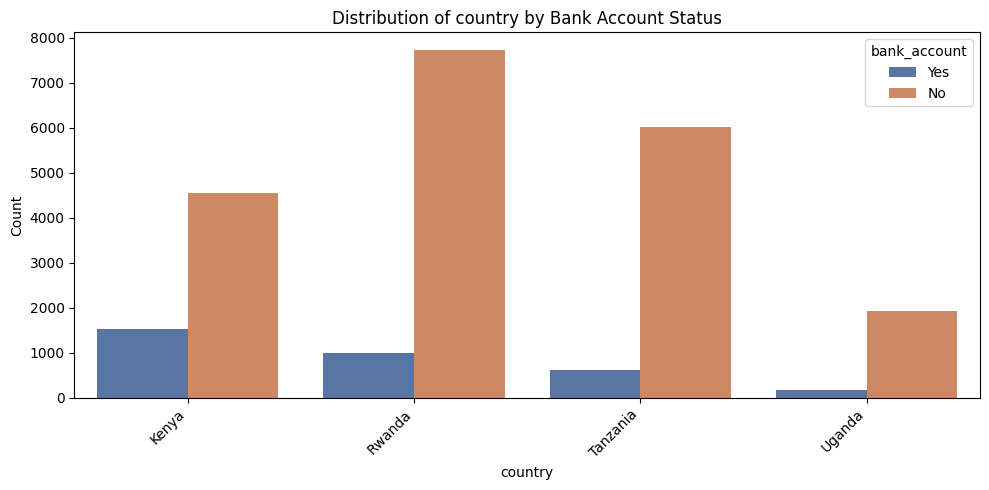

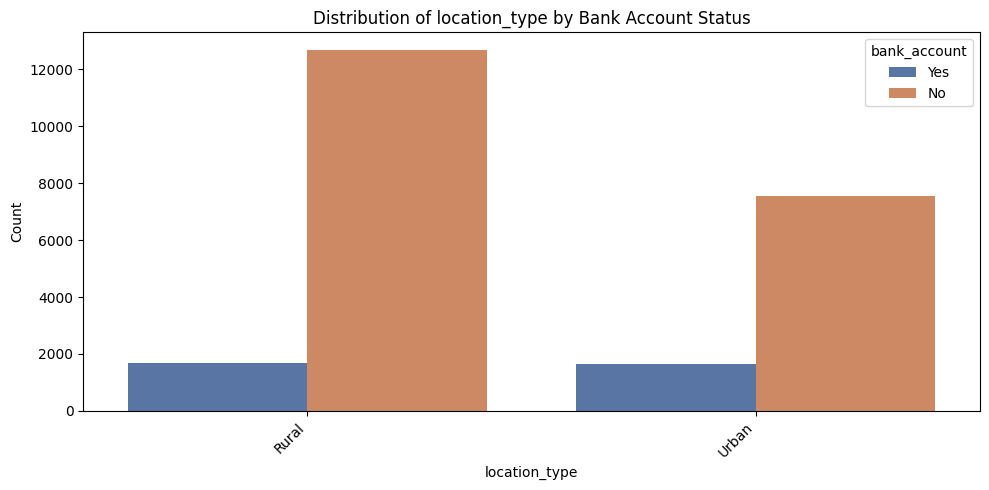

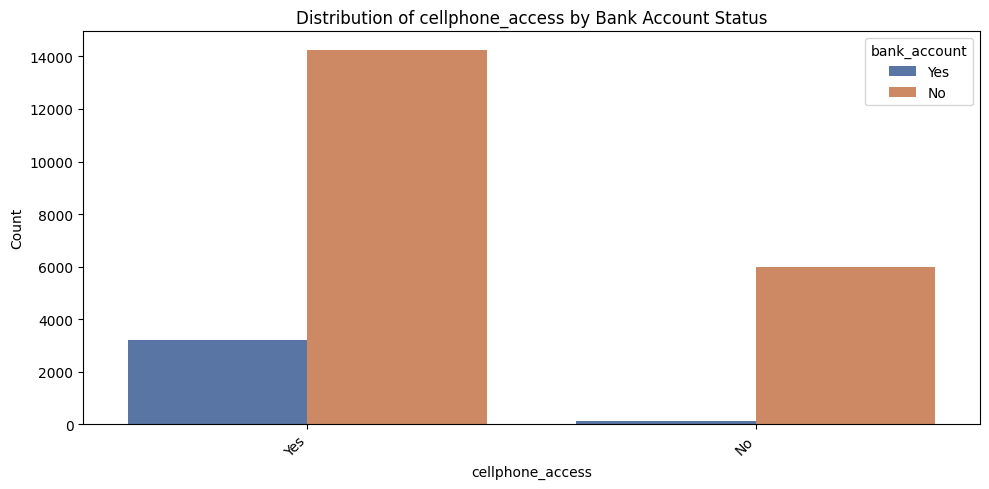

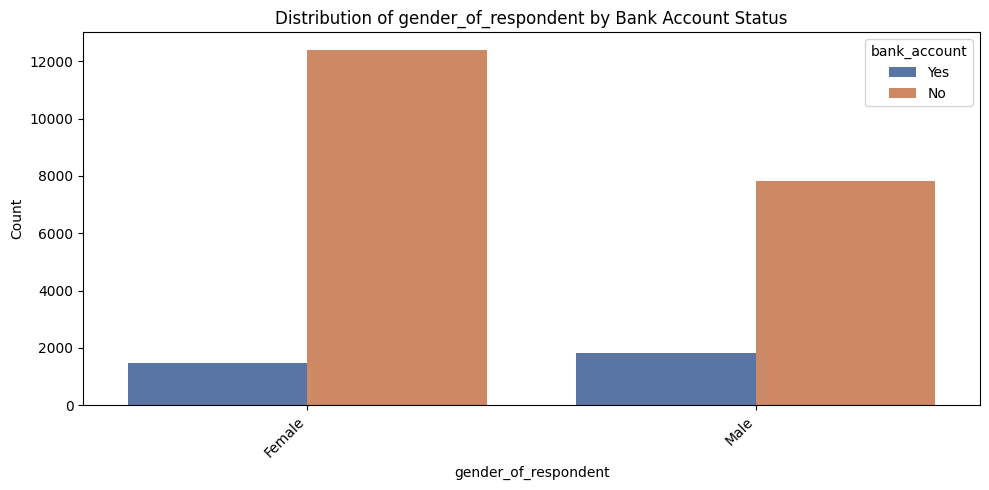

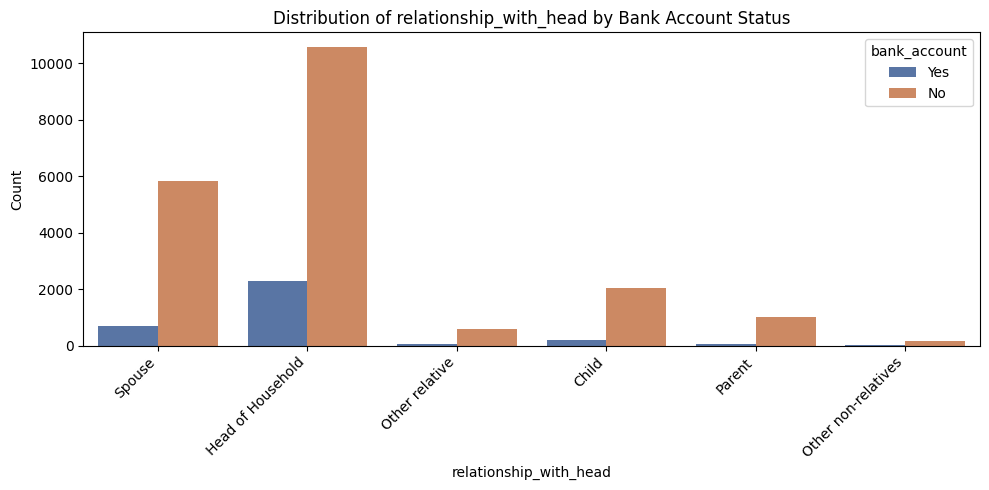

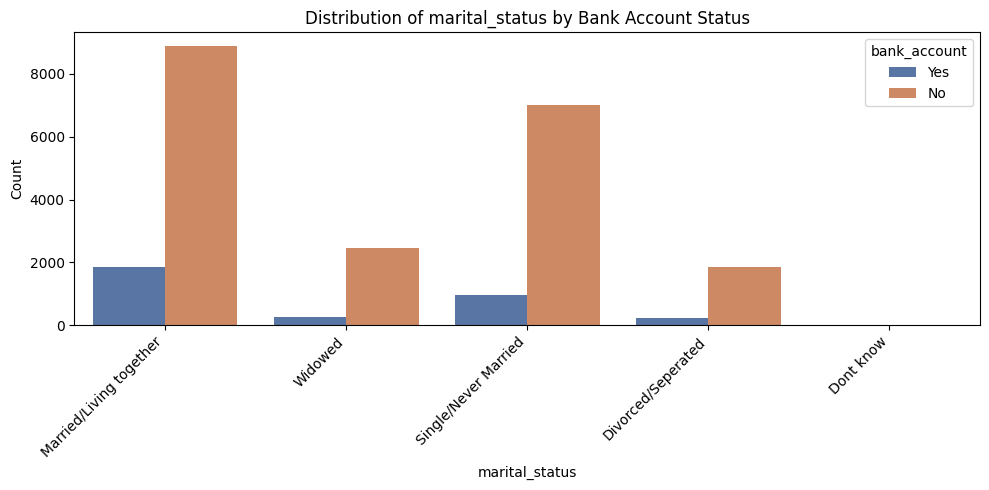

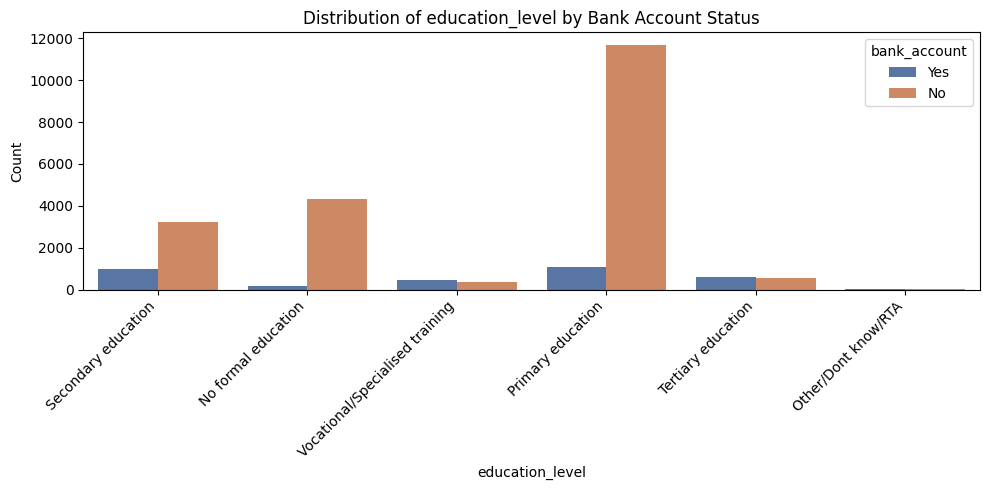

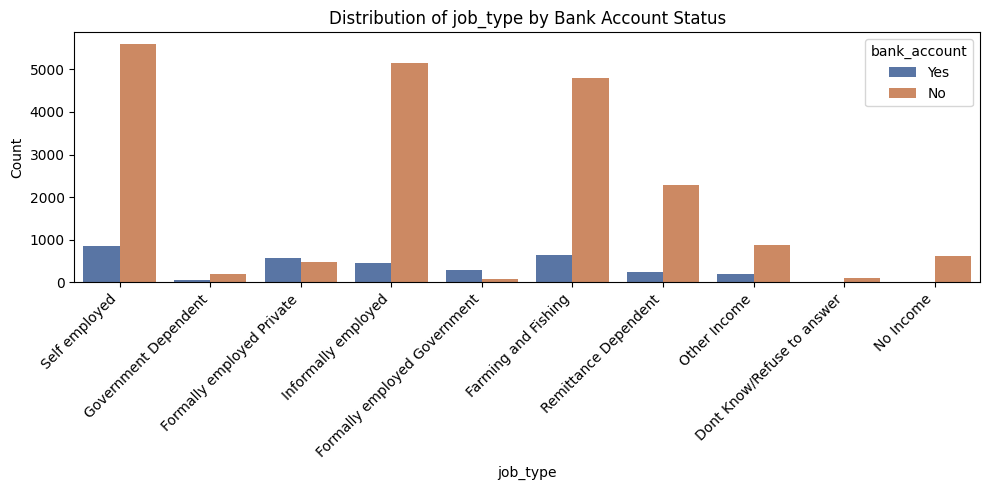

In [135]:
categorical_cols = train.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('uniqueid')
categorical_cols.remove('bank_account')

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='bank_account', data=train, palette='deep')
    plt.title(f'Distribution of {col} by Bank Account Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

These plots give us a visual understanding of how different categorical features are distributed and how they relate to having a bank account. For instance, we can see differences across countries, location types, genders, and education levels.

Next, we should examine the numerical features: `household_size` and `age_of_respondent`. This will help us identify potential correlations or patterns.

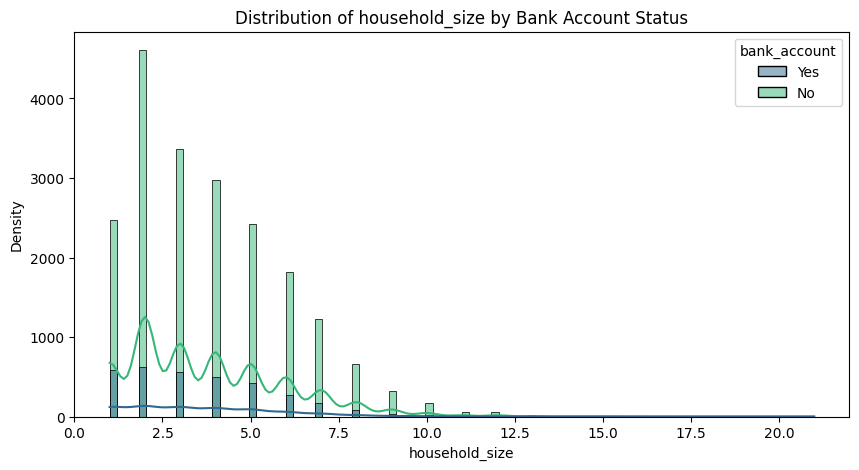

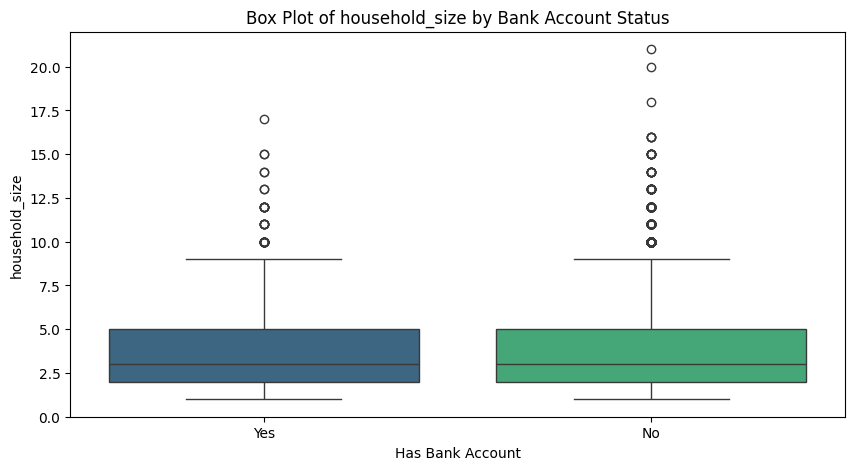

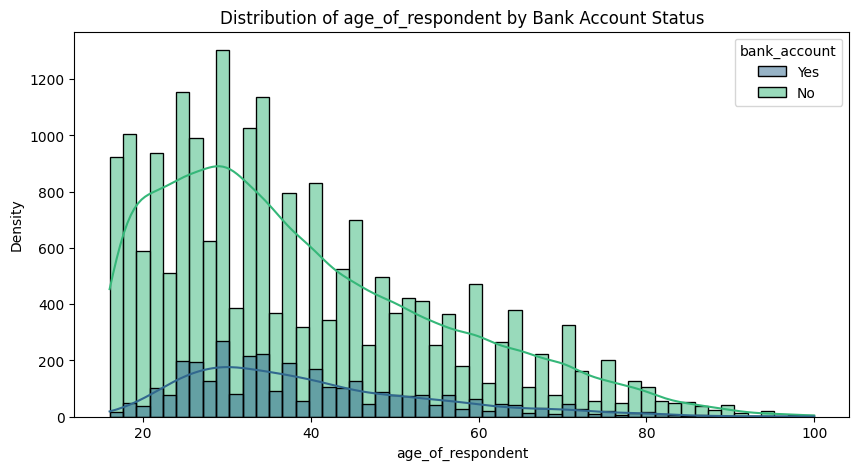

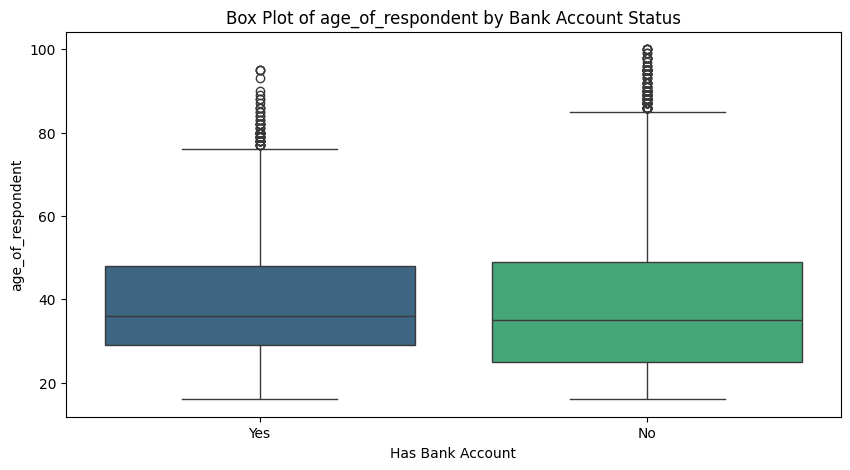

In [136]:
numerical_cols = ['household_size', 'age_of_respondent']
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=train, x=col, hue='bank_account', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by Bank Account Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=train, x='bank_account', y=col, palette='viridis', hue='bank_account', legend=False)
    plt.title(f'Box Plot of {col} by Bank Account Status')
    plt.xlabel('Has Bank Account')
    plt.ylabel(col)
    plt.show()

Correlatioin analysis

Text(0.5, 1.0, 'Feature Correlation')

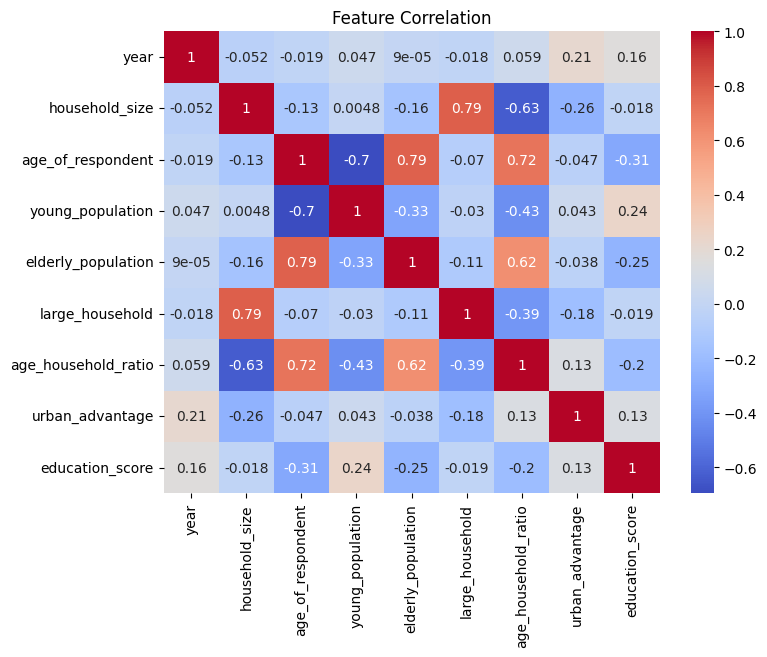

In [137]:
plt.figure(figsize=(8,6))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")

## Data Preprocessing


In [138]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying the original DataFrames directly
train_processed = train.copy()
test_processed = test.copy()

# Convert 'Yes' to 1 and 'No' to 0
train_processed['bank_account'] = train_processed['bank_account'].map({'Yes': 1, 'No': 0})

#. Drop 'uniqueid' from both train and test datasets as it's an identifier
train_processed = train_processed.drop('uniqueid', axis=1)
test_processed = test_processed.drop('uniqueid', axis=1)

# CatBoost can handle object types directly, but it's good practice to list them
categorical_features_indices = []
categorical_features_names = []

for i, col in enumerate(train_processed.drop('bank_account', axis=1).columns):
    if train_df_processed[col].dtype == 'object':
        categorical_features_indices.append(i)
        categorical_features_names.append(col)

print(f"Categorical features identified: {categorical_features_names}")
print(f"Indices of categorical features: {categorical_features_indices}")

print('\nProcessed Train DataFrame Head:')
display(train_processed.head())
print('\nProcessed Test DataFrame Head:')
display(test_processed.head())

Categorical features identified: ['country', 'location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']
Indices of categorical features: [0, 2, 3, 6, 7, 8, 9, 10]

Processed Train DataFrame Head:


,country,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,young_population,elderly_population,large_household,age_household_ratio,urban_advantage,education_score
0,Kenya,2018,1,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed,1,0,0,6.000000,0,2
1,Kenya,2018,0,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent,0,1,0,11.666667,0,0
2,Kenya,2018,1,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,1,0,0,4.333333,1,3
3,Kenya,2018,0,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,0,0,0,5.666667,0,1
4,Kenya,2018,0,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed,1,0,1,2.888889,1,1



Processed Test DataFrame Head:


,country,year,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,young_population,elderly_population,large_household,age_household_ratio,urban_advantage,education_score
0,Kenya,2018,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government,0,0,0,7.500000,1,2
1,Kenya,2018,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private,0,0,1,6.375000,1,3
2,Kenya,2018,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent,0,1,0,19.250000,0,0
3,Kenya,2018,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent,0,0,1,5.571429,0,1
4,Kenya,2018,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent,1,0,0,4.000000,1,2


## Model Training with CatBoost

I'll use CatBoost Classifier, as it's well-suited for tabular data and can handle categorical features directly, which aligns with our dataset. We'll split our data into features (X) and the target variable (y), then train the model.

In [139]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
import numpy as np

X = train_processed.drop('bank_account', axis=1)
y = train_processed['bank_account']

# Convert column names to string for CatBoost compatibility if they are not already
X.columns = X.columns.astype(str)
test_processed.columns = test_processed.columns.astype(str)

cat_params = {
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 3,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 50
}

# Initialize CatBoost model
model = CatBoostClassifier(**cat_params)

print("\nTraining CatBoost Model...")

#
model.fit(
    X,
    y,
    cat_features=categorical_features_names,
)

print("\nCatBoost Model Training Complete!")


Training CatBoost Model...
0:	total: 98.7ms	remaining: 1m 38s
100:	total: 12.8s	remaining: 1m 54s
200:	total: 23.7s	remaining: 1m 34s
300:	total: 28.9s	remaining: 1m 7s
400:	total: 35.9s	remaining: 53.6s
500:	total: 41.6s	remaining: 41.5s
600:	total: 49.3s	remaining: 32.7s
700:	total: 55.2s	remaining: 23.5s
800:	total: 1m 2s	remaining: 15.6s
900:	total: 1m 8s	remaining: 7.54s
999:	total: 1m 16s	remaining: 0us

CatBoost Model Training Complete!


In [140]:
feature_importance = model.get_feature_importance()

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

feat_imp.head(20)

,Feature,Importance
5,age_of_respondent,12.414879
3,cellphone_access,12.024234
10,job_type,11.745011
14,age_household_ratio,11.147671
0,country,10.888214
9,education_level,7.146315
8,marital_status,6.544816
16,education_score,5.860204
7,relationship_with_head,5.837736
6,gender_of_respondent,3.366309


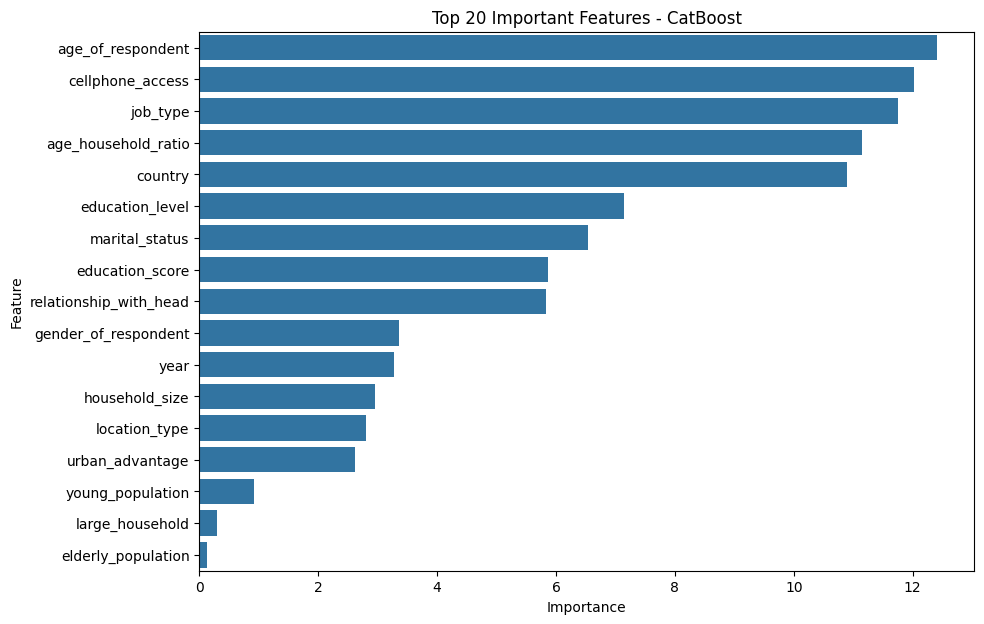

In [141]:
plt.figure(figsize=(10,7))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feat_imp.head(20)
)

plt.title("Top 20 Important Features - CatBoost")
plt.show()

prediction i do

In [142]:
test_pred_proba = model.predict_proba(test_processed)[:, 1]


test_predictions = (test_pred_proba >= 0.3).astype(int)

print("\nPredictions made on the test set.")


Predictions made on the test set.


# Here i'm also use StratifiedKFold

Instead of training once:

Data is split into 5 parts (folds)
Each fold becomes validation once
Model trains 5 different times

and my prediction also included

In [143]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, mean_absolute_error, roc_auc_score
import numpy as np

# Number of folds for cross-validation
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds = np.zeros((X.shape[0],))
test_preds_proba_list = []
model_auc_scores = []
model_mae_scores = []

print(f"\nStarting {N_SPLITS}-Fold Stratified Cross-Validation with updated parameters...")
print(f"CatBoost parameters being used: {cat_params}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold + 1}/{N_SPLITS} ---")

    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    # Re-initialize model for each fold to ensure clean training
    fold_model = CatBoostClassifier(**cat_params)

    fold_model.fit(
        X_train,
        y_train,
        cat_features=categorical_features_names,
        eval_set=(X_val, y_val),
        early_stopping_rounds=cat_params['early_stopping_rounds'],
        verbose=False # Set to True for verbose output during fold training
    )

    # Out-of-fold predictions for validation set
    oof_preds[val_idx] = fold_model.predict_proba(X_val)[:, 1]

    # Predictions for the test set
    test_preds_proba_list.append(fold_model.predict_proba(test_processed)[:, 1])

    # To Evaluate the fold model
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    fold_mae = mean_absolute_error(y_val, (oof_preds[val_idx] >= 0.5).astype(int))

    model_auc_scores.append(fold_auc)
    model_mae_scores.append(fold_mae)

    print(f"Fold {fold + 1} - AUC: {fold_auc:.4f}, MAE: {fold_mae:.4f}")

print("\nCross-Validation Complete!")



Starting 5-Fold Stratified Cross-Validation with updated parameters...
CatBoost parameters being used: {'iterations': 1000, 'learning_rate': 0.05, 'depth': 8, 'l2_leaf_reg': 3, 'loss_function': 'Logloss', 'eval_metric': 'AUC', 'random_seed': 42, 'verbose': 100, 'early_stopping_rounds': 50}

--- Fold 1/5 ---
Fold 1 - AUC: 0.8667, MAE: 0.1148

--- Fold 2/5 ---
Fold 2 - AUC: 0.8628, MAE: 0.1124

--- Fold 3/5 ---
Fold 3 - AUC: 0.8735, MAE: 0.1071

--- Fold 4/5 ---
Fold 4 - AUC: 0.8663, MAE: 0.1105

--- Fold 5/5 ---
Fold 5 - AUC: 0.8636, MAE: 0.1135

Cross-Validation Complete!


#prediction

In [144]:
# Aggregate OOF predictions and test predictions
final_oof_auc = roc_auc_score(y, oof_preds)
final_oof_mae = mean_absolute_error(y, (oof_preds >= 0.5).astype(int))

print(f"\nOverall OOF AUC: {final_oof_auc:.4f}")
print(f"Overall OOF MAE: {final_oof_mae:.4f}")
print(f"Average Fold AUC: {np.mean(model_auc_scores):.4f} +/- {np.std(model_auc_scores):.4f}")
print(f"Average Fold MAE: {np.mean(model_mae_scores):.4f} +/- {np.std(model_mae_scores):.4f}")

# Average predictions from all folds for the test set
final_test_pred_proba = np.mean(test_preds_proba_list, axis=0)
final_test_predictions = (final_test_pred_proba >= 0.5).astype(int)

print("\nFinal predictions on the test set generated via cross-validation.")


Overall OOF AUC: 0.8661
Overall OOF MAE: 0.1117
Average Fold AUC: 0.8666 +/- 0.0038
Average Fold MAE: 0.1117 +/- 0.0027

Final predictions on the test set generated via cross-validation.


here i'm combinet the two prediction i do both by catboost and StratifiedKFold to take the average of them

In [145]:

pred_single = np.array(test_pred_proba)
pred_cv = np.array(final_test_pred_proba)

# weighted blending (CV is stronger → give more weight)
blended_proba = (0.3 * pred_single) + (0.7 * pred_cv)

blended_predictions = (blended_proba >= 0.5).astype(int)

In [146]:
submission = pd.DataFrame({
    'uniqueid': test['uniqueid'] + ' x ' + test['country'],
    'bank_account': blended_predictions
})

submission_filename = 'mysumbission_file.csv'
submission.to_csv(submission_filename, index=False)

print(f"Final combined file is'{submission_filename}'")
print(submission.head())

Final combined file is'mysumbission_file.csv'
                uniqueid  bank_account
0  uniqueid_6056 x Kenya             1
1  uniqueid_6060 x Kenya             1
2  uniqueid_6065 x Kenya             0
3  uniqueid_6072 x Kenya             0
4  uniqueid_6073 x Kenya             0


#to check the submission file

In [147]:
print(submission.shape)
print(submission.head())

(10086, 2)
                uniqueid  bank_account
0  uniqueid_6056 x Kenya             1
1  uniqueid_6060 x Kenya             1
2  uniqueid_6065 x Kenya             0
3  uniqueid_6072 x Kenya             0
4  uniqueid_6073 x Kenya             0


to check prediction values i do for 1 and 0

In [148]:
print(submission['bank_account'].value_counts())

bank_account
0    9390
1     696
Name: count, dtype: int64


In [149]:
assert submission.shape[0] == len(test), "Row mismatch!"
assert submission.isnull().sum().sum() == 0, "Missing values detected!"
assert submission['uniqueid'].duplicated().sum() == 0, "Duplicate IDs found!"
print("✔ Submission file is valid and safe to submit")

✔ Submission file is valid and safe to submit


to dowload the file submission i do on this colab

In [150]:
from google.colab import files

files.download("mysumbission_file.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>